# Etapa 1 · Preprocesado de tremordb

Dataset: *Effect of Deep Brain Stimulation on Parkinsonian Tremor* (PhysioNet tremordb v1.0.0).

Pipeline: descarga → parseo de nombres y `.hea` → lectura de señales → filtrado pasa-banda 1–20 Hz → ventaneo + z-score por sujeto → división por sujeto (12/2/2).

Salidas para etapas 2 y 3: `tremor_X_{train,val,test}.npy`, `tremor_y_{train,val,test}.npy`, `scalers.json`, `metadata.csv`, `label_dict.json`.

In [1]:
!pip install wfdb -q
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
import os, re, json
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

## 1. Descarga del dataset (~3.5 MB)

In [2]:
import urllib.request
from urllib.parse import urljoin

BASE_URL = 'https://physionet.org/files/tremordb/1.0.0/'
DATA_DIR = Path('./tremordb')
DATA_DIR.mkdir(exist_ok=True)

def fetch_html(url):
    req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
    with urllib.request.urlopen(req, timeout=30) as resp:
        return resp.read().decode('utf-8', errors='ignore')

def list_files_recursive(url, depth=0):
    # Escanea recursivamente .let/.rit/.hea/.dat bajo url
    try:
        html = fetch_html(url)
    except Exception as e:
        print(f'  fallo {url}: {e}')
        return []
    out = []
    for href in re.findall(r'href="([^"]+)"', html):
        if href.startswith(('?', '#', '/', 'http://', 'https://')) or href == '../':
            continue
        full_url = urljoin(url, href)
        if not full_url.startswith(BASE_URL):
            continue
        if href.endswith('/'):
            out.extend(list_files_recursive(full_url, depth + 1))
        elif re.search(r'\.(let|rit|hea|dat)$', href, re.IGNORECASE):
            out.append(full_url)
    return out


if not list(DATA_DIR.rglob('*.let')):
    all_urls = list_files_recursive(BASE_URL)
    print(f'{len(all_urls)} archivos encontrados, descargando...')
    fail = []
    for i, url in enumerate(all_urls, 1):
        rel = url[len(BASE_URL):]
        out = DATA_DIR / rel
        out.parent.mkdir(parents=True, exist_ok=True)
        if out.exists() and out.stat().st_size > 0:
            continue
        try:
            urllib.request.urlretrieve(url, out)
        except Exception as e:
            fail.append((rel, str(e)))
    print(f'Descarga lista (fallos: {len(fail)})')
else:
    print('Dataset ya descargado.')

all_files = sorted(list(DATA_DIR.rglob('*.let')) + list(DATA_DIR.rglob('*.rit')))
print(f'Total de archivos de señal: {len(all_files)}')

117 archivos encontrados, descargando...
Descarga lista (fallos: 0)
Total de archivos de señal: 101


## 2. Parseo de nombres + cabeceras `.hea`

Convención de nombres (Beuter et al., 2001 + docs de PhysioNet):

```
{target}{subj}r{dbs}{med}.{lado}
```

- `target` ∈ {v=Vim, s=STN, g=GPi}
- `subj` 1–16
- `dbs` ∈ {e = DBS ON; o = DBS OFF; Xo = DBS OFF X min}
- `med` ∈ {n = MED ON, f = MED OFF}
- `lado`: `.let` izquierdo, `.rit` derecho

Cada `.hea` contiene la tabla de anotaciones con `fs`, `range` y `samples` por archivo.

In [3]:
FILENAME_RE = re.compile(r'^(?P<target>[vsg])(?P<subj>\d{1,2})r(?P<dbs>e|o|\d+o)(?P<med>[nf])$')
TARGET_MAP = {'v': 'Vim', 's': 'STN', 'g': 'GPi'}

def parse_filename(filepath):
    p = Path(filepath)
    m = FILENAME_RE.match(p.stem.lower())
    if m is None:
        return None
    subj_num = int(m.group('subj'))
    if not 1 <= subj_num <= 16:
        return None
    dbs_raw = m.group('dbs')
    if dbs_raw == 'e':
        dbs_state, dbs_off_min = 'ON', None
    elif dbs_raw == 'o':
        dbs_state, dbs_off_min = 'OFF', None
    else:
        dbs_state, dbs_off_min = 'OFF', int(dbs_raw[:-1])
    med = 'ON' if m.group('med') == 'n' else 'OFF'
    return {
        'filepath':    str(filepath),
        'target':      TARGET_MAP[m.group('target')],
        'subject_num': subj_num,
        'subject_id':  f"{m.group('target')}{subj_num}",
        'group':       'HAT' if subj_num <= 8 else 'LAT',
        'dbs_state':   dbs_state,
        'dbs_off_min': dbs_off_min,
        'medication':  med,
        'side':        'left' if p.suffix.lower() == '.let' else 'right',
        'condition':   f'DBS_{dbs_state}_MED_{med}',
    }


def parse_hea(hea_path):
    # Devuelve {filename: {fs, range, samples}} a partir de la tabla del .hea multi-segmento.
    meta = {}
    fs = None
    in_table = False
    for line in Path(hea_path).read_text().splitlines():
        if fs is None and not line.startswith('#') and not line.startswith(' '):
            parts = line.split()
            if len(parts) >= 3:
                try:
                    fs = int(parts[2])
                except ValueError:
                    pass
        if line.startswith('# SUBJ') and 'FILE' in line:
            in_table = True
            continue
        if in_table and line.startswith('#'):
            cols = line.lstrip('#').split()
            if len(cols) >= 7:
                try:
                    meta[cols[1]] = {'range': float(cols[2]),
                                     'samples': int(cols[6]),
                                     'fs': int(cols[5])}
                except (ValueError, IndexError):
                    pass
            elif 'SAMPLES:' in line or '=' in line:
                in_table = False
    return meta


# Construir mapa global filename → metadatos de hea
ALL_FILE_META = {}
for hea in Path('./tremordb').rglob('*.hea'):
    ALL_FILE_META.update(parse_hea(hea))

# Construir df_meta combinando nombres + .hea
records, failures = [], []
for f in all_files:
    m = parse_filename(f)
    if m is None:
        failures.append(f.name)
        continue
    h = ALL_FILE_META.get(f.name, {})
    m.update({'fs': h.get('fs'), 'range_ms': h.get('range'), 'samples': h.get('samples')})
    records.append(m)

df_meta = pd.DataFrame(records)
print(f'Parseados: {len(df_meta)}, fallidos: {len(failures)}')
if failures:
    print('  ejemplos fallidos:', failures[:5])

print(f'\nfs:    {df_meta["fs"].value_counts(dropna=False).to_dict()}')
print(f'range: {df_meta["range_ms"].value_counts(dropna=False).to_dict()}')
print(f'\nCondicion x grupo:\n{df_meta.groupby(["condition","group"]).size().unstack(fill_value=0)}')

Parseados: 101, fallidos: 0

fs:    {100.0: 97, nan: 4}
range: {0.5: 48, 0.2: 24, 2.0: 11, 0.1: 9, 1.0: 5, nan: 4}

Condicion x grupo:
group            HAT  LAT
condition                
DBS_OFF_MED_OFF   20   40
DBS_OFF_MED_ON     7    8
DBS_ON_MED_OFF     5    8
DBS_ON_MED_ON      5    8


## 3. Lectura de señales + validación

Cada `.let`/`.rit` es texto ASCII normalizado a [-1, 1]; se reescala con `range` del `.hea` para obtener m/s. Se descartan registros < 10 s (umbral elegido para garantizar al menos 8 ventanas de 1.2 s con 50% de solape).

In [4]:
def load_signal(filepath):
    # Lee .let/.rit (ASCII), reescala con RANGE del .hea a m/s.
    p = Path(filepath)
    try:
        with open(p) as f:
            sig = np.array([float(l.strip()) for l in f if l.strip()], dtype=np.float32)
    except Exception as e:
        print(f'  error de lectura {p.name}: {e}')
        return None, None
    if len(sig) == 0:
        return None, None
    sig = np.nan_to_num(sig, nan=0.0)
    meta = ALL_FILE_META.get(p.name, {})
    fs = int(meta.get('fs') or 100)
    rng = meta.get('range')
    if rng is not None and rng > 0:
        sig = sig * float(rng)
    return sig, fs


DUR_MIN_S = 10.0   # >= 8 ventanas de 1.2 s con 50% solape

rows = []
for _, r in df_meta.iterrows():
    sig, fs = load_signal(r['filepath'])
    if sig is None:
        rows.append({**r.to_dict(), 'duration_s': None, 'rms': None, 'ok': False})
        continue
    rows.append({
        **r.to_dict(),
        'duration_s': len(sig) / fs,
        'rms':        float(np.sqrt(np.mean(sig**2))),
        'ok':         True,
    })

df_diag = pd.DataFrame(rows)
df_clean = df_diag[df_diag['ok'] & (df_diag['duration_s'] >= DUR_MIN_S)].copy()
print(f'Lectura ok: {df_diag["ok"].sum()}/{len(df_diag)}')
print(f'Retenidos (>= {DUR_MIN_S}s): {len(df_clean)}')
print(f'Duracion s: mean={df_diag["duration_s"].mean():.1f}, range=[{df_diag["duration_s"].min():.1f}, {df_diag["duration_s"].max():.1f}]')

Lectura ok: 101/101
Retenidos (>= 10.0s): 101
Duracion s: mean=67.1, range=[34.0, 121.1]


## 4. EDA · dominio temporal y PSD

Sujeto HAT con la cobertura más amplia de condiciones, 4 condiciones básicas (DBS × MED).

Sujeto: g2


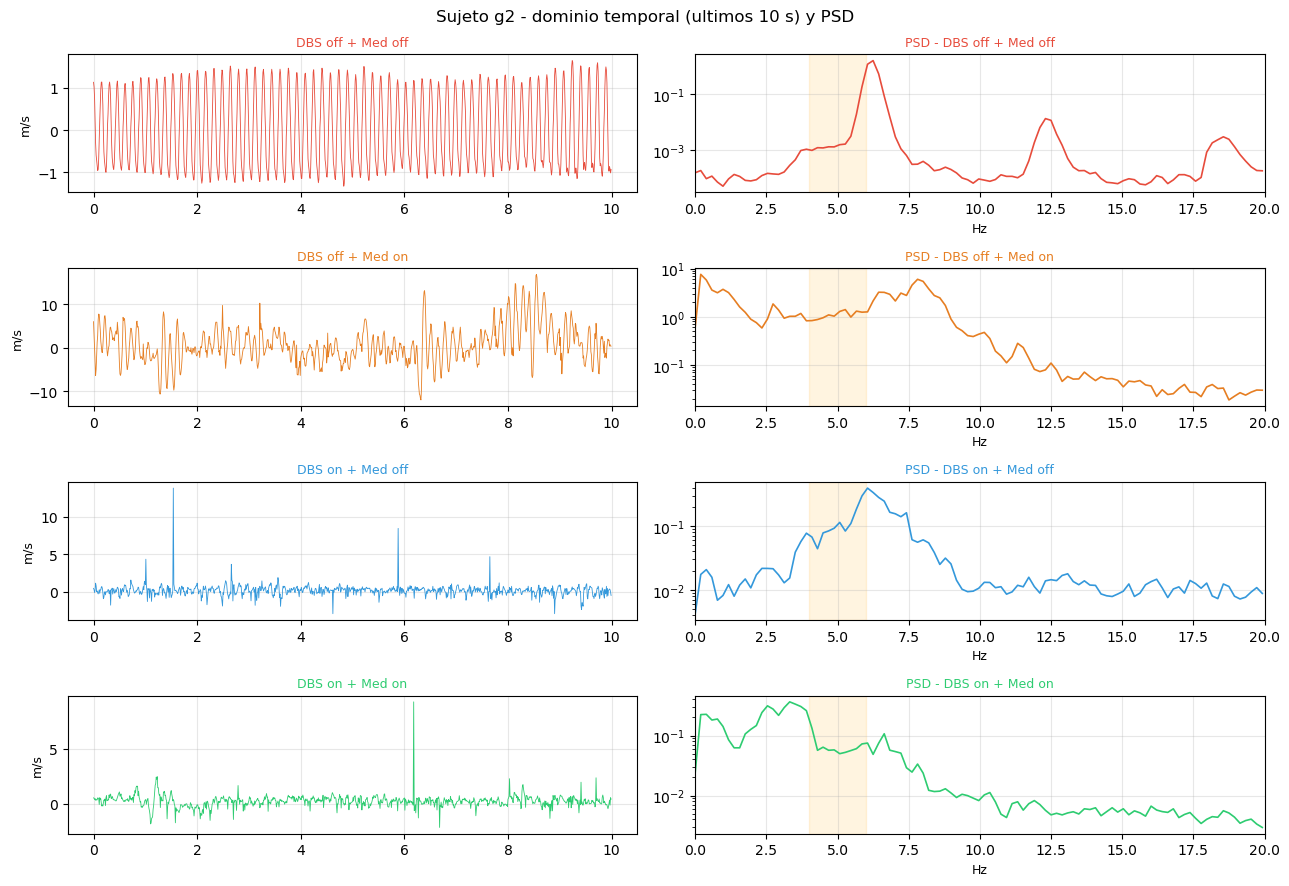

In [5]:
BASIC_CONDITIONS = ['DBS_OFF_MED_OFF', 'DBS_OFF_MED_ON', 'DBS_ON_MED_OFF', 'DBS_ON_MED_ON']
COND_LABELS = ['DBS off + Med off', 'DBS off + Med on', 'DBS on + Med off', 'DBS on + Med on']
COND_COLORS = ['#e74c3c', '#e67e22', '#3498db', '#2ecc71']

hat_df = df_clean[df_clean['group'] == 'HAT']
target_subj = hat_df.groupby('subject_id')['condition'].nunique().idxmax()
print(f'Sujeto: {target_subj}')

fig, axes = plt.subplots(4, 2, figsize=(13, 9))
fig.suptitle(f'Sujeto {target_subj} - dominio temporal (ultimos 10 s) y PSD')

for i, (cond, label, color) in enumerate(zip(BASIC_CONDITIONS, COND_LABELS, COND_COLORS)):
    sub = df_clean[(df_clean['subject_id'] == target_subj) & (df_clean['condition'] == cond)]
    ax_t, ax_f = axes[i, 0], axes[i, 1]
    if len(sub) == 0:
        for ax in (ax_t, ax_f):
            ax.text(0.5, 0.5, f'{label}\n(sin datos)', ha='center', va='center', transform=ax.transAxes, color='gray')
            ax.set_xticks([]); ax.set_yticks([])
        continue
    sig, fs = load_signal(sub.iloc[0]['filepath'])
    n = min(10 * fs, len(sig))
    t = np.arange(n) / fs
    ax_t.plot(t, sig[:n], color=color, lw=0.6)
    ax_t.set_title(label, color=color, fontsize=9)
    ax_t.set_ylabel('m/s', fontsize=9); ax_t.grid(alpha=0.3)

    f_psd, psd = signal.welch(sig, fs=fs, nperseg=min(512, len(sig)))
    mask = f_psd <= 20
    ax_f.semilogy(f_psd[mask], psd[mask], color=color, lw=1.2)
    ax_f.axvspan(4, 6, color='orange', alpha=0.12)
    ax_f.set_title(f'PSD - {label}', color=color, fontsize=9)
    ax_f.set_xlabel('Hz', fontsize=9); ax_f.grid(alpha=0.3); ax_f.set_xlim(0, 20)

plt.tight_layout()
plt.savefig('eda_subject_panel.png', dpi=130, bbox_inches='tight')
plt.show()

## 5. Estadisticos de banda de temblor

Por condicion: frecuencia pico, ratio de energia en 4-6 Hz, RMS. Se espera que DBS_OFF_MED_OFF tenga la mayor proporcion en la banda 4-6 Hz.

In [6]:
# Calcular features y firmar metadata.csv en una sola pasada.
feat_rows = []
for _, r in df_clean.iterrows():
    sig, fs = load_signal(r['filepath'])
    if sig is None:
        continue
    f_psd, psd = signal.welch(sig, fs=fs, nperseg=min(512, len(sig)))
    band = (f_psd >= 4) & (f_psd <= 6)
    feat_rows.append({
        **r.to_dict(),
        'peak_freq_hz':       float(f_psd[np.argmax(psd)]),
        'tremor_band_ratio':  float(psd[band].sum() / (psd.sum() + 1e-12)),
    })

df_feat = pd.DataFrame(feat_rows)
agg = df_feat.groupby('condition').agg(
    peak_freq_mean=('peak_freq_hz', 'mean'),
    peak_freq_std=('peak_freq_hz', 'std'),
    band_ratio_mean=('tremor_band_ratio', 'mean'),
    band_ratio_std=('tremor_band_ratio', 'std'),
    rms_mean=('rms', 'mean'),
).round(3)
print(agg)
df_feat.to_csv('metadata.csv', index=False)

                 peak_freq_mean  peak_freq_std  band_ratio_mean  \
condition                                                         
DBS_OFF_MED_OFF           5.632          1.719            0.348   
DBS_OFF_MED_ON            3.503          3.282            0.111   
DBS_ON_MED_OFF            5.709          1.433            0.335   
DBS_ON_MED_ON             3.891          3.293            0.099   

                 band_ratio_std  rms_mean  
condition                                  
DBS_OFF_MED_OFF           0.328     3.260  
DBS_OFF_MED_ON            0.152     2.340  
DBS_ON_MED_OFF            0.282     2.962  
DBS_ON_MED_ON             0.058     1.674  


## 6. Bandpass 1-20 Hz + ventaneo + z-score por sujeto

- Filtro Butterworth pasa-banda orden 4 (cubre la banda de temblor 4-6 Hz mas armonicos y deriva de baja frecuencia).
- Ventana 1.2 s, solape 50% -> 240 muestras a 200 Hz (~5-7 ciclos de temblor).
- z-score por sujeto: **sigma sobre la senal concatenada filtrada**. Tras el bandpass la media es ~0, por lo que se centra opcionalmente y la normalizacion se basa en sigma. Se persiste (mu, sigma) en `scalers.json` para desnormalizar a m/s en etapas posteriores.

In [7]:
from scipy.signal import butter, sosfiltfilt

def bandpass(sig, fs, low=1.0, high=20.0, order=4):
    sos = butter(order, [low / (fs/2), high / (fs/2)], btype='band', output='sos')
    return sosfiltfilt(sos, sig).astype(np.float32)


WINDOW_SEC = 1.2
OVERLAP    = 0.5
TARGET_FS  = 200
WINDOW_LEN = int(WINDOW_SEC * TARGET_FS)
step       = int(WINDOW_LEN * (1 - OVERLAP))

# Solo las 4 condiciones basicas
df_use = df_feat[df_feat['condition'].isin(BASIC_CONDITIONS)].copy()
print(f'Para modelado: {len(df_use)} registros, {df_use["subject_id"].nunique()} sujetos')

# Pre-cargar todas las senales filtradas (y resampleadas a TARGET_FS) en un dict para no leerlas dos veces.
prepped = {}   # filepath -> signal filtrada en TARGET_FS
for fp in df_use['filepath']:
    sig, fs = load_signal(fp)
    if sig is None:
        continue
    if fs != TARGET_FS:
        sig = signal.resample_poly(sig, TARGET_FS, fs).astype(np.float32)
    prepped[fp] = bandpass(sig, TARGET_FS)

# Calcular (mu, sigma) por sujeto sobre la concatenacion ya filtrada.
# Tras bandpass mu ~ 0 pero lo guardamos para mantener la convencion z-score y poder revertir.
scalers = {}
for sid, rows in df_use.groupby('subject_id'):
    chunks = [prepped[fp] for fp in rows['filepath'] if fp in prepped]
    if chunks:
        cat = np.concatenate(chunks)
        scalers[sid] = {'mu': float(cat.mean()), 'sigma': float(cat.std() + 1e-8)}

print(f'Escaladores: {len(scalers)} sujetos. mu medio ~ {np.mean([s["mu"] for s in scalers.values()]):.2e} (esperado ~0 tras bandpass)')

# Ventanear + z-score
COND_IDX   = {c: i for i, c in enumerate(BASIC_CONDITIONS)}
TARGET_IDX = {'Vim': 0, 'GPi': 1, 'STN': 2}
GROUP_IDX  = {'HAT': 0, 'LAT': 1}

X_all, y_all = [], []
for _, row in df_use.iterrows():
    if row['filepath'] not in prepped or row['subject_id'] not in scalers:
        continue
    sig = prepped[row['filepath']]
    sc = scalers[row['subject_id']]
    sig = (sig - sc['mu']) / sc['sigma']
    s = 0
    while s + WINDOW_LEN <= len(sig):
        X_all.append(sig[s:s + WINDOW_LEN])
        y_all.append([COND_IDX[row['condition']],
                      TARGET_IDX[row['target']],
                      GROUP_IDX[row['group']],
                      int(row['subject_num'])])
        s += step

X_all = np.stack(X_all).astype(np.float32)
y_all = np.array(y_all, dtype=np.int64)
print(f'\nX={X_all.shape}, y={y_all.shape}')
for c, idx in COND_IDX.items():
    print(f'  {c}: {(y_all[:, 0] == idx).sum()} ventanas')

Para modelado: 101 registros, 15 sujetos
Escaladores: 15 sujetos. mu medio ~ 4.86e-05 (esperado ~0 tras bandpass)

X=(11145, 240), y=(11145, 4)
  DBS_OFF_MED_OFF: 6570 ventanas
  DBS_OFF_MED_ON: 1769 ventanas
  DBS_ON_MED_OFF: 1418 ventanas
  DBS_ON_MED_ON: 1388 ventanas


## 7. Division por sujeto

Particion estratificada por grupo HAT/LAT: 1 sujeto de cada grupo a val, 1 a test, el resto a train. Evita la fuga de ventanas del mismo individuo entre splits.

In [8]:
all_subjects = df_use[['subject_id', 'group', 'subject_num']].drop_duplicates().reset_index(drop=True)
rng = np.random.RandomState(42)

val_subj, test_subj = [], []
for grp in ['HAT', 'LAT']:
    candidates = all_subjects[all_subjects['group'] == grp]['subject_id'].values
    chosen = rng.choice(candidates, size=2, replace=False)
    val_subj.append(chosen[0]); test_subj.append(chosen[1])

train_subj = [s for s in all_subjects['subject_id'].values if s not in val_subj + test_subj]
print(f'Train: {train_subj}')
print(f'Val:   {val_subj}')
print(f'Test:  {test_subj}')

# Reconstruir subject_id por ventana desde y_all (target_idx, subject_num) -> 'v3', 'g11', etc.
TARGET_LETTER = {0: 'v', 1: 'g', 2: 's'}
window_sids = np.array([f'{TARGET_LETTER[t]}{n}' for t, n in zip(y_all[:, 1], y_all[:, 3])])

train_mask = np.isin(window_sids, train_subj)
val_mask   = np.isin(window_sids, val_subj)
test_mask  = np.isin(window_sids, test_subj)

X_train, y_train = X_all[train_mask], y_all[train_mask]
X_val,   y_val   = X_all[val_mask],   y_all[val_mask]
X_test,  y_test  = X_all[test_mask],  y_all[test_mask]
print(f'\nTrain {X_train.shape}, Val {X_val.shape}, Test {X_test.shape}')

Train: ['s8', 'g11', 'g12', 'g13', 'g9', 's15', 's16', 's7', 'g1', 'v4', 'v5']
Val:   ['g2', 's14']
Test:  ['s6', 'g10']

Train (7485, 240), Val (1761, 240), Test (1899, 240)


## 8. Ejemplos de ventanas (una por condicion)

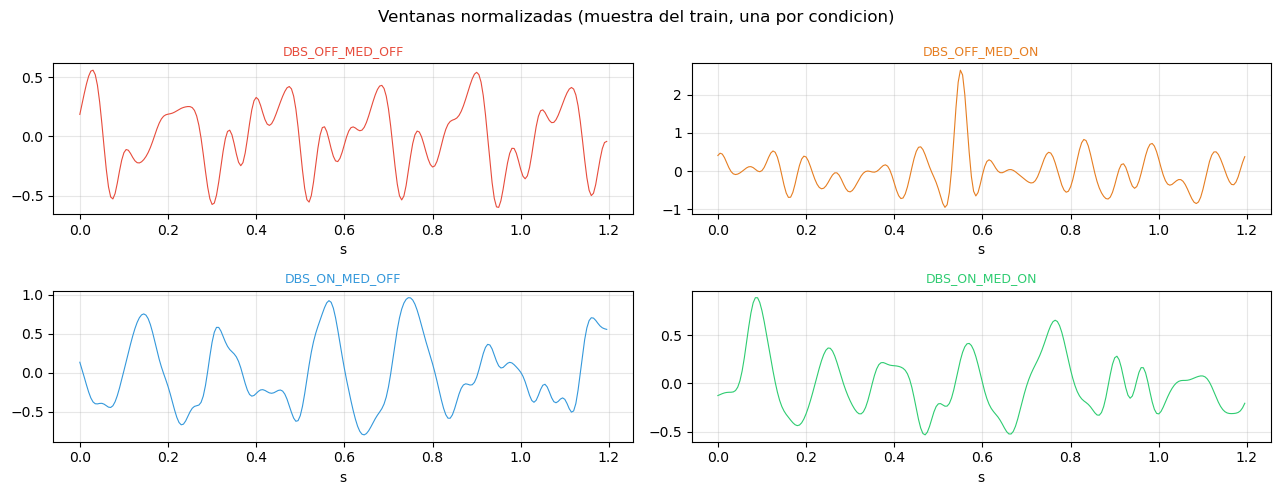

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(13, 5))
fig.suptitle('Ventanas normalizadas (muestra del train, una por condicion)')
t = np.arange(WINDOW_LEN) / TARGET_FS

for ax, (cond, idx) in zip(axes.flat, COND_IDX.items()):
    cand = np.where(y_train[:, 0] == idx)[0]
    if len(cand) == 0:
        ax.text(0.5, 0.5, 'sin datos', ha='center', va='center', transform=ax.transAxes); continue
    pick = rng.choice(cand)
    ax.plot(t, X_train[pick], color=COND_COLORS[idx], lw=0.8)
    ax.set_title(cond, color=COND_COLORS[idx], fontsize=9)
    ax.set_xlabel('s'); ax.grid(alpha=0.3)

plt.tight_layout(); plt.savefig('window_examples.png', dpi=130, bbox_inches='tight'); plt.show()

## 9. Guardar artefactos

In [10]:
np.save('tremor_X_train.npy', X_train); np.save('tremor_y_train.npy', y_train)
np.save('tremor_X_val.npy',   X_val);   np.save('tremor_y_val.npy',   y_val)
np.save('tremor_X_test.npy',  X_test);  np.save('tremor_y_test.npy',  y_test)

label_dict = {
    'condition':     COND_IDX,
    'condition_inv': {v: k for k, v in COND_IDX.items()},
    'target':        TARGET_IDX,
    'group':         GROUP_IDX,
    'columns':       ['condition_idx', 'target_idx', 'group_idx', 'subject_num'],
    'window_sec':    WINDOW_SEC,
    'window_len':    WINDOW_LEN,
    'sampling_rate': TARGET_FS,
    'overlap':       OVERLAP,
    'split':         {'train': train_subj, 'val': val_subj, 'test': test_subj},
}
with open('label_dict.json', 'w', encoding='utf-8') as f:
    json.dump(label_dict, f, indent=2, ensure_ascii=False)
with open('scalers.json', 'w', encoding='utf-8') as f:
    json.dump(scalers, f, indent=2, ensure_ascii=False)

for f in ['tremor_X_train.npy', 'tremor_y_train.npy',
          'tremor_X_val.npy',   'tremor_y_val.npy',
          'tremor_X_test.npy',  'tremor_y_test.npy',
          'label_dict.json', 'scalers.json', 'metadata.csv']:
    if os.path.exists(f):
        print(f'  {f}  ({os.path.getsize(f)/1e6:.2f} MB)')

  tremor_X_train.npy  (7.19 MB)
  tremor_y_train.npy  (0.24 MB)
  tremor_X_val.npy  (1.69 MB)
  tremor_y_val.npy  (0.06 MB)
  tremor_X_test.npy  (1.82 MB)
  tremor_y_test.npy  (0.06 MB)
  label_dict.json  (0.00 MB)
  scalers.json  (0.00 MB)
  metadata.csv  (0.01 MB)


## Resumen

| Item | Valor |
|---|---|
| Sujetos | 16 (HAT 8, LAT 8) |
| Filtro | Butterworth pasa-banda 1-20 Hz, orden 4 |
| Remuestreo | 200 Hz |
| Ventana | 1.2 s, solape 50% (240 muestras) |
| Normalizacion | z-score por sujeto |
| Split | 12 train / 2 val / 2 test (por sujeto) |

Etapa 2: cargar `tremor_X_train.npy` para entrenar el CVAE.